In [15]:
from paddy_data_loader import load_train_val_test_data
import matplotlib.pyplot as plt

## Load Data and check number of samples

In [2]:
train_loader, val_loader, test_loader = load_train_val_test_data(batch_size=32)

In [3]:
# count samples in each set
print(f"Number of training samples: {len(train_loader.dataset)}")
print(f"Number of validation samples: {len(val_loader.dataset)}")
print(f"Number of test samples: {len(test_loader.dataset)}")

Number of training samples: 8323
Number of validation samples: 1036
Number of test samples: 1048


## Class Names and image samples from each class

In [9]:
# class name of sample data
class_names = test_loader.dataset.classes
# Replace underscores with spaces and capitalize each word
class_names = [name.replace("_", " ").title() for name in class_names]
print(f"Class names: {class_names}")

Class names: ['Bacterial Leaf Blight', 'Bacterial Leaf Streak', 'Bacterial Panicle Blight', 'Blast', 'Brown Spot', 'Dead Heart', 'Downy Mildew', 'Hispa', 'Normal', 'Tungro']


In [10]:
# TAKE ONE IMAGE FROM EACH CLASS IN THE Train/test/validation DATASET.
# This will take a bit of time, change to test for faster process
sample_images = []
for class_index in range(len(class_names)):
    for image, label in val_loader.dataset:
        if label == class_index:
            sample_images.append((image, label))
            break

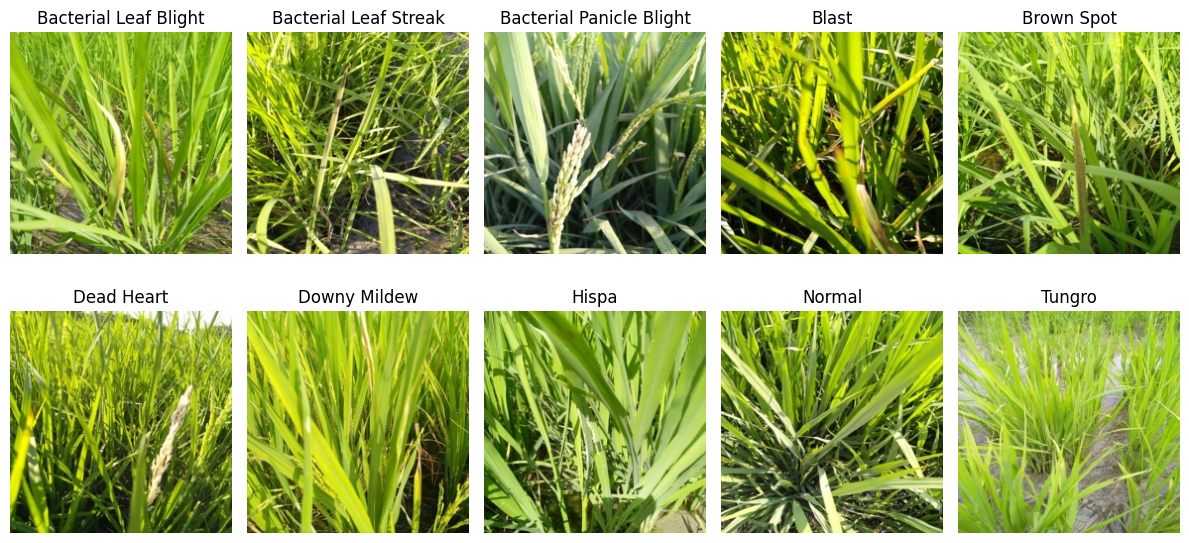

In [12]:
plt.figure(figsize=(12, 6))
for i in range(10):
    image, label = sample_images[i]
    image = image.permute(1, 2, 0).numpy()  # convert from (C, H, W) to (H, W, C)
    class_name = class_names[label]
    title = class_name.replace("_", " ").title()
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
#plt.savefig("sample_data_visualization.png", dpi=300)
plt.show()

## Train, Test, Validation Distribution

In [13]:
train_class_counts = [0] * 10
for _, label in train_loader.dataset:
    train_class_counts[label] += 1
    

val_class_counts = [0] * 10
for _, label in val_loader.dataset:
    val_class_counts[label] += 1

test_class_counts = [0] * 10
for _, label in test_loader.dataset:
    test_class_counts[label] += 1

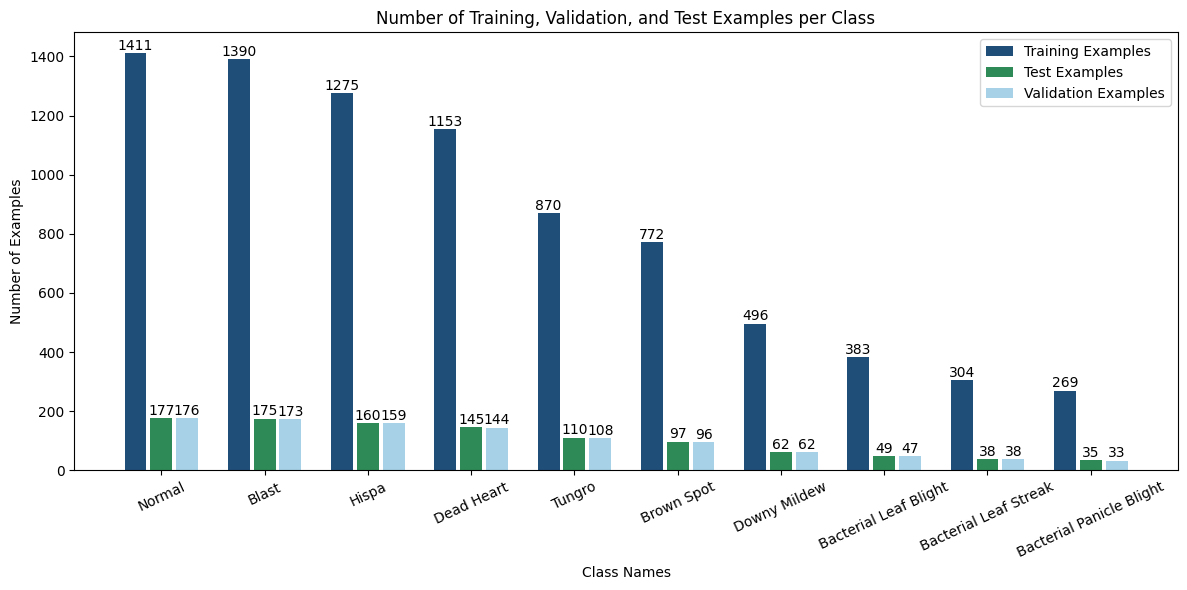

In [14]:
sorted_indices = np.argsort(train_class_counts)[::-1]
sorted_class_names = [class_names[i] for i in sorted_indices]
sorted_train_counts = [train_class_counts[i] for i in sorted_indices]
sorted_val_counts = [val_class_counts[i] for i in sorted_indices]
sorted_test_counts = [test_class_counts[i] for i in sorted_indices]

x = np.arange(len(class_names))
width = 0.25
bar_width = width * 0.85

plt.figure(figsize=(12, 6))

plt.bar(x - width, sorted_train_counts, bar_width, label="Training Examples", color="#1F4E79")
plt.bar(x, sorted_test_counts, bar_width, label="Test Examples", color="#2E8B57")
plt.bar(x + width, sorted_val_counts, bar_width, label="Validation Examples", color="#A6D1E6")

plt.xlabel("Class Names")
plt.ylabel("Number of Examples")
plt.title("Number of Training, Validation, and Test Examples per Class")
plt.xticks(x, sorted_class_names, rotation=25)

plt.legend()

# One-line text loop for all datasets
for offset, counts in zip([-width, 0, width], [sorted_train_counts, sorted_test_counts, sorted_val_counts]):
    [plt.text(xi + offset, val + 1, str(val), ha="center", va="bottom") for xi, val in zip(x, counts)]

plt.tight_layout()
# plt.savefig("class_distribution.png", dpi=300)
plt.show()